
## Imports 

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso, BayesianRidge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


## Régression — Prédiction de `Prix_Revente`


### Chargement des données

In [27]:
df_clean = pd.read_csv("../data/df_clean.csv")

### Features / Target

In [28]:
target = "Prix_Revente"
features = [c for c in df_clean.columns if c not in [target, "Rapport_Collecte"]]

X = df_clean[features]
y = df_clean[target]

print("Features:", features)
print("Shape X:", X.shape)

Features: ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Categorie', 'Source']
Shape X: (9724, 7)


### SPLIT 70 / 15 / 15 

In [29]:
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=42
)

print("\nSplit:")
print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)


Split:
Train: (6806, 7)
Val  : (1459, 7)
Test : (1459, 7)


### Scaling

In [30]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


### Fonction d’évaluation

In [31]:
def eval_reg(name, model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    y_pred = model.predict(Xte)

    mse = mean_squared_error(yte, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(yte, y_pred)
    r2 = r2_score(yte, y_pred)

    print(f"{name:25s} | RMSE={rmse:.4f} | MAE={mae:.4f} | MSE={mse:.4f} | R2={r2:.4f}")

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MSE": mse,
        "R2": r2,
        "y_pred": y_pred
    }

### MODELES COMPLETS

In [32]:
models = {
    "Régression linéaire": LinearRegression(),

    "Régression Ridge": Ridge(alpha=1),

    "Régression Lasso": Lasso(alpha=0.1, max_iter=5000),

    "Régression polynomiale": Pipeline([
        ("poly", PolynomialFeatures(degree=2)),
        ("lr", LinearRegression())
    ]),

    "Bayesian Ridge": BayesianRidge(),

    "DecisionTreeRegressor": DecisionTreeRegressor(random_state=42),

    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=100, random_state=42, n_jobs=-1
    ),

    "GradientBoosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),

    "KNN": KNeighborsRegressor(n_neighbors=5),

    "SVR (RBF)": SVR(kernel="rbf")
}

### TRAIN + EVALUATION

In [33]:
print("\n=== REGRESSION RESULTS ===")

reg_results = {}

for name, model in models.items():
    reg_results[name] = eval_reg(
        name,
        model,
        X_train_scaled,
        y_train,
        X_test_scaled,
        y_test
    )


=== REGRESSION RESULTS ===
Régression linéaire       | RMSE=1.2462 | MAE=0.7454 | MSE=1.5530 | R2=0.9383
Régression Ridge          | RMSE=1.2462 | MAE=0.7457 | MSE=1.5531 | R2=0.9383
Régression Lasso          | RMSE=1.2815 | MAE=0.8282 | MSE=1.6422 | R2=0.9348
Régression polynomiale    | RMSE=0.9882 | MAE=0.4978 | MSE=0.9765 | R2=0.9612
Bayesian Ridge            | RMSE=1.2462 | MAE=0.7455 | MSE=1.5530 | R2=0.9383
DecisionTreeRegressor     | RMSE=0.4996 | MAE=0.1110 | MSE=0.2496 | R2=0.9901
RandomForestRegressor     | RMSE=0.4174 | MAE=0.1088 | MSE=0.1742 | R2=0.9931
GradientBoosting          | RMSE=0.5409 | MAE=0.2166 | MSE=0.2926 | R2=0.9884
KNN                       | RMSE=0.7283 | MAE=0.1889 | MSE=0.5304 | R2=0.9789
SVR (RBF)                 | RMSE=0.9304 | MAE=0.3276 | MSE=0.8656 | R2=0.9656


### Summary

In [34]:
results_df = pd.DataFrame({
    k: {m: v for m, v in r.items() if m != "y_pred"}
    for k, r in reg_results.items()
}).T.sort_values("R2", ascending=False)

display(results_df)

,RMSE,MAE,MSE,R2
RandomForestRegressor,0.417414,0.108819,0.174234,0.993081
DecisionTreeRegressor,0.499550,0.111038,0.249551,0.990090
GradientBoosting,0.540937,0.216645,0.292613,0.988380
KNN,0.728270,0.188904,0.530377,0.978939
SVR (RBF),0.930362,0.327617,0.865574,0.965628
Régression polynomiale,0.988169,0.497805,0.976477,0.961224
Régression linéaire,1.246186,0.745373,1.552981,0.938332
Bayesian Ridge,1.246197,0.745520,1.553006,0.938331
Régression Ridge,1.246214,0.745749,1.553050,0.938329
Régression Lasso,1.281472,0.828182,1.642171,0.934790


### GridSearch (Tuning)

In [35]:
from sklearn.model_selection import GridSearchCV

print("\n=== GridSearch - Gradient Boosting Regressor ===")


param_grid_gbr = {
    'n_estimators': [100, 150],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_gbr = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid_gbr,
    cv=3,                 
    scoring='r2',
    n_jobs=-1             # utilise tous les cores
)

# entraînement
grid_gbr.fit(X_train_scaled, y_train)

# meilleur modèle
best_gbr = grid_gbr.best_estimator_

print("Best params:", grid_gbr.best_params_)
print("Best CV R2:", grid_gbr.best_score_)

# prédiction
y_pred_gbr_grid = best_gbr.predict(X_test_scaled)

# métriques complètes
mse = mean_squared_error(y_test, y_pred_gbr_grid)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_gbr_grid)
r2 = r2_score(y_test, y_pred_gbr_grid)

print("\nGradient Boosting (GridSearch)")
print("RMSE:", rmse)
print("MAE :", mae)
print("MSE :", mse)
print("R2  :", r2)

# ajout dans résultats
reg_results['Gradient Boosting (GridSearch)'] = {
    "RMSE": rmse,
    "MAE": mae,
    "MSE": mse,
    "R2": r2,
    "y_pred": y_pred_gbr_grid
}


=== GridSearch - Gradient Boosting Regressor ===


BrokenProcessPool: A task has failed to un-serialize. Please ensure that the arguments of the function are all picklable.

### GRAPHIQUE RÉELS vs PRÉDITS

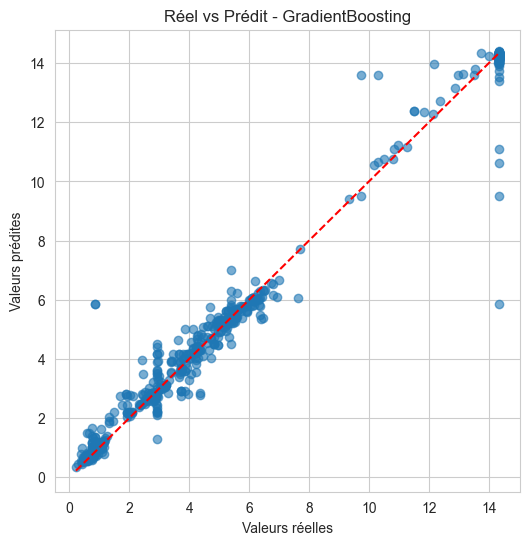

In [ ]:
best_model_name = results_df.index[0]
best_preds = reg_results[best_model_name]["y_pred"]

plt.figure(figsize=(6,6))
plt.scatter(y_test, best_preds, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title(f"Réel vs Prédit - {best_model_name}")
plt.show()